In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/raw/synthetic_children.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,age_months,sex,weight_kg,height_cm,muac_cm,waz,haz,whz,underweight_status,stunting_status,wasting_status,sam_muac_flag,mam_muac_flag
0,5,M,5.01,61.1,12.1,-2.13,-1.22,-1.73,moderate,normal,normal,False,True
1,46,M,15.21,103.3,14.7,-0.34,0.26,-0.42,normal,normal,normal,False,False
2,39,F,15.13,100.7,15.2,0.34,0.86,0.06,normal,normal,normal,False,False
3,26,F,4.60,78.0,10.6,-4.38,-2.36,-3.63,severe,moderate,severe,True,False
4,25,F,8.46,84.8,12.6,-1.98,-0.44,-1.84,normal,normal,normal,False,False


In [3]:
df.shape

(5000, 13)

In [4]:
df.columns

Index(['age_months', 'sex', 'weight_kg', 'height_cm', 'muac_cm', 'waz', 'haz',
       'whz', 'underweight_status', 'stunting_status', 'wasting_status',
       'sam_muac_flag', 'mam_muac_flag'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age_months          5000 non-null   int64  
 1   sex                 5000 non-null   str    
 2   weight_kg           5000 non-null   float64
 3   height_cm           5000 non-null   float64
 4   muac_cm             5000 non-null   float64
 5   waz                 5000 non-null   float64
 6   haz                 5000 non-null   float64
 7   whz                 5000 non-null   float64
 8   underweight_status  5000 non-null   str    
 9   stunting_status     5000 non-null   str    
 10  wasting_status      5000 non-null   str    
 11  sam_muac_flag       5000 non-null   bool   
 12  mam_muac_flag       5000 non-null   bool   
dtypes: bool(2), float64(6), int64(1), str(4)
memory usage: 439.6 KB


In [6]:
df.describe()   

,age_months,weight_kg,height_cm,muac_cm,waz,haz,whz
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.420000,11.135148,85.709140,13.837820,-0.741706,-0.519880,-0.574618
std,17.363902,4.137506,15.568319,1.211845,1.321380,1.005615,1.068976
min,0.000000,1.500000,41.900000,9.700000,-5.340000,-4.110000,-4.350000
25%,14.000000,8.037500,74.975000,13.000000,-1.850000,-1.160000,-1.330000
50%,29.000000,11.060000,88.100000,14.200000,-0.180000,-0.240000,-0.210000
75%,45.000000,14.552500,98.200000,14.700000,0.180000,0.200000,0.190000
max,59.000000,20.450000,115.500000,16.200000,1.280000,1.660000,1.440000


In [7]:
df.isnull().sum()

age_months            0
sex                   0
weight_kg             0
height_cm             0
muac_cm               0
waz                   0
haz                   0
whz                   0
underweight_status    0
stunting_status       0
wasting_status        0
sam_muac_flag         0
mam_muac_flag         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["underweight_status"].value_counts()

underweight_status
normal      3848
moderate     724
severe       428
Name: count, dtype: int64

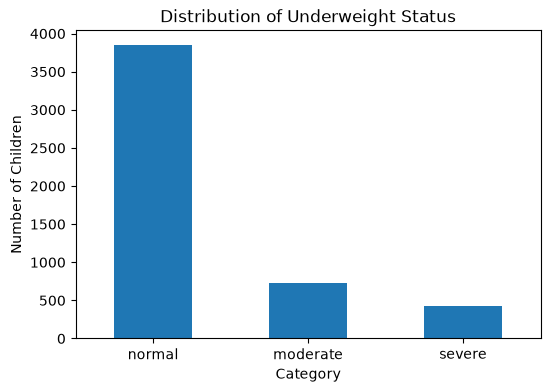

In [10]:
df["underweight_status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Underweight Status")
plt.xlabel("Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)

plt.show()

In [11]:
df["stunting_status"].value_counts()

stunting_status
normal      4419
moderate     518
severe        63
Name: count, dtype: int64

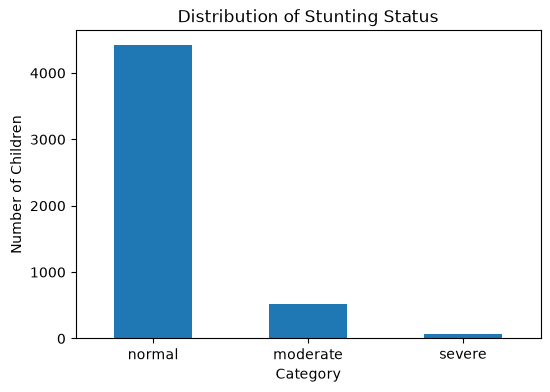

In [12]:
df["stunting_status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Stunting Status")
plt.xlabel("Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)

plt.show()

In [13]:
df["wasting_status"].value_counts()

wasting_status
normal      4259
moderate     628
severe       113
Name: count, dtype: int64

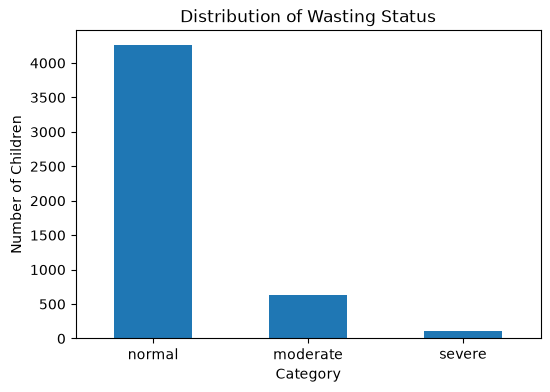

In [14]:
df["wasting_status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Wasting Status")
plt.xlabel("Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)

plt.show()

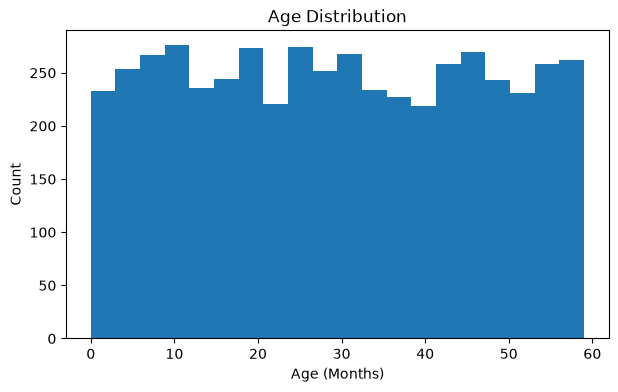

In [15]:
plt.figure(figsize=(7,4))

plt.hist(df["age_months"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age (Months)")
plt.ylabel("Count")

plt.show()

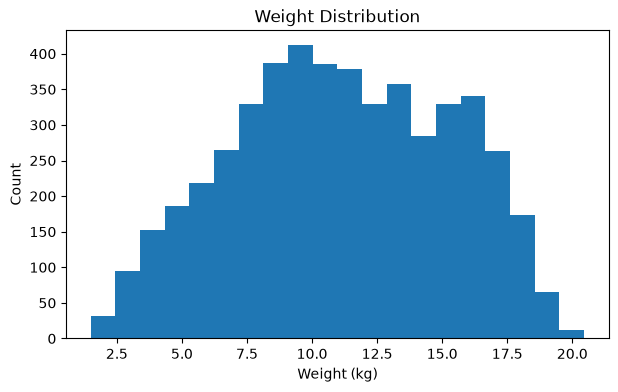

In [16]:
plt.figure(figsize=(7,4))

plt.hist(df["weight_kg"], bins=20)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")

plt.show()

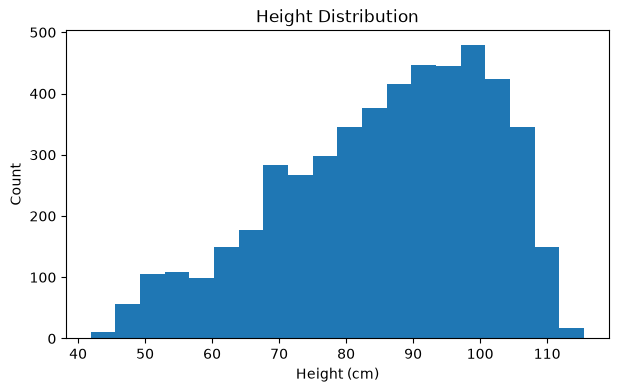

In [17]:
plt.figure(figsize=(7,4))

plt.hist(df["height_cm"], bins=20)

plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Count")

plt.show()

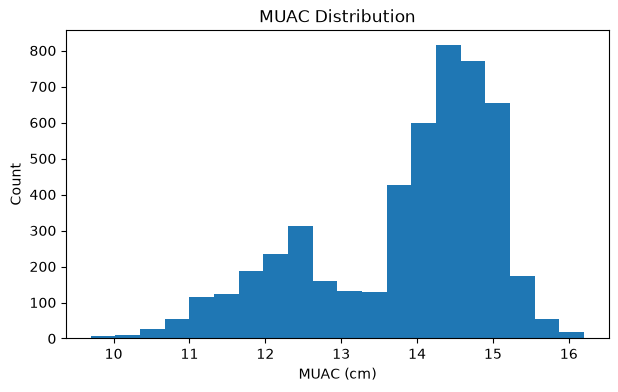

In [18]:
plt.figure(figsize=(7,4))

plt.hist(df["muac_cm"], bins=20)

plt.title("MUAC Distribution")
plt.xlabel("MUAC (cm)")
plt.ylabel("Count")

plt.show()

In [19]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.corr()

,age_months,weight_kg,height_cm,muac_cm,waz,haz,whz
age_months,1.000000,0.796059,0.939624,0.000148,0.001232,-0.013473,0.005619
weight_kg,0.796059,1.000000,0.908253,0.483179,0.559354,0.451484,0.554878
height_cm,0.939624,0.908253,1.000000,0.205016,0.214763,0.244545,0.191510
muac_cm,0.000148,0.483179,0.205016,1.000000,0.863788,0.791177,0.828447
waz,0.001232,0.559354,0.214763,0.863788,1.000000,0.828432,0.985551
haz,-0.013473,0.451484,0.244545,0.791177,0.828432,1.000000,0.721618
whz,0.005619,0.554878,0.191510,0.828447,0.985551,0.721618,1.000000
